Our goal is to train a ML classifier to predict convection onset. We will be using environmental variables from ERA5 for our input matrix and precipitation flags from TOOCAN for our target vector.

**Disclaimer**: The following code was written with the help of Gemini.

In [31]:
import xarray as xr
import pandas as pd
import numpy as np
import warnings
import glob
import os

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [32]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [33]:
era5_dir = '/glade/work/addisus/GPM_TOOCAN_data/era5_select'
toocan_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan/'
toocan_temp_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_TbExpand'
toocan_precip_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_CnvStrNorainFlag'

# Create Dataframes

In [34]:
def get_common_dates():
    date_sets = []
    for directory in [era5_dir, toocan_dir, toocan_temp_dir, toocan_precip_dir]:
        dates = {
            name[:8]
            for name in os.listdir(directory)
            if len(name) >= 8 and name[:8].isdigit()
        }
        date_sets.append(dates)

    common_dates = sorted(set.intersection(*date_sets))
    return common_dates


common_dates = get_common_dates()
common_dates[:5]  # first 5 common dates

['20140319', '20140320', '20140321', '20140322', '20140323']

In [35]:
def find_sample(date, dir):
    sample = ""
    for d in os.listdir(dir):
        if date in d:
            sample = d
            break
    return sample

def find_paths(date):
    sample_era5 = find_sample(date, era5_dir)
    sample_toocan = find_sample(date, toocan_dir)
    sample_toocan_temp = find_sample(date, toocan_temp_dir)
    era5_path = os.path.join(era5_dir, sample_era5)
    toocan_path = os.path.join(toocan_dir, sample_toocan)
    toocan_temp_path = os.path.join(toocan_temp_dir, sample_toocan_temp)
    return era5_path, toocan_path, toocan_temp_path

In [36]:
def build_ml_matrix(era5_path, toocan_path, toocan_temp_path, date_string):
    # 3. Use 'with' to automatically close files and prevent OS memory crashes
    with xr.open_dataset(era5_path) as ds_era5, \
         xr.open_dataset(toocan_path) as ds_toocan, \
         xr.open_dataset(toocan_temp_path) as ds_temp:
        
        matrix_rows = []
        
        nt = ds_toocan.sizes['nt']
        nsysmax = ds_toocan.sizes['nsysmax']
        
        era5_time_idx = 0  
        
        for t in range(nt):
            grid_dcs_ids = ds_temp['DCS_number'].values[t, :, :]
            grid_tb = ds_temp['Tb'].values[t, :, :]
            
            for s in range(nsysmax):
                dcs_id = ds_toocan['DCS_number'].values[t, s]
                if np.isnan(dcs_id) or dcs_id <= 0:
                    continue 
                    
                # --- Target Label ---
                grids_all = ds_toocan['ngrids'].values[:, t, s]
                if np.all(np.isnan(grids_all)) or np.all(grids_all <= 0) or np.all(grids_all <= -9000):
                    continue 
                
                convective_grids = grids_all[0]
                target_y = 1 if (not np.isnan(convective_grids) and convective_grids > 0) else 0
                    
                # --- TOOCAN Temp Aggregation ---
                system_mask = (grid_dcs_ids == dcs_id)
                if np.any(system_mask):
                    tb_values = grid_tb[system_mask]
                    tb_values = tb_values[tb_values > -9000] 
                    tb_min = np.min(tb_values) if len(tb_values) > 0 else np.nan
                    tb_mean = np.mean(tb_values) if len(tb_values) > 0 else np.nan
                else:
                    tb_min, tb_mean = np.nan, np.nan

                # --- ERA5 CAPE & Percentiles ---
                era5_grids = ds_era5['ngrids'].values[0, t, s]
                
                if not np.isnan(era5_grids) and era5_grids >= 4:
                    cape_mean = ds_era5['CAPE'].values[era5_time_idx, 0, t, s]
                    cape_25   = ds_era5['CAPE'].values[era5_time_idx, 1, t, s]
                    cape_50   = ds_era5['CAPE'].values[era5_time_idx, 2, t, s]
                    cape_75   = ds_era5['CAPE'].values[era5_time_idx, 3, t, s]
                elif not np.isnan(era5_grids) and era5_grids > 0:
                    valid_grids = int(era5_grids)
                    raw_capes = ds_era5['CAPE'].values[era5_time_idx, 0:valid_grids, t, s]
                    
                    # 1. FIX: Mask missing values BEFORE calculating the mean
                    raw_capes = np.where(raw_capes <= -9000, np.nan, raw_capes)
                    cape_mean = np.nanmean(raw_capes) if not np.all(np.isnan(raw_capes)) else np.nan
                    cape_25, cape_50, cape_75 = np.nan, np.nan, np.nan
                else:
                    cape_mean, cape_25, cape_50, cape_75 = np.nan, np.nan, np.nan, np.nan

                # --- ERA5 Vertical Profiles ---
                uprof = ds_era5['uprof'].values[era5_time_idx, t, s, :]
                vprof = ds_era5['vprof'].values[era5_time_idx, t, s, :] 
                
                if not np.isnan(era5_grids) and era5_grids >= 4:
                    tprof = ds_era5['tprof'].values[era5_time_idx, 0, t, s, :] 
                    qprof = ds_era5['qprof'].values[era5_time_idx, 0, t, s, :]
                elif not np.isnan(era5_grids) and era5_grids > 0:
                    valid_grids = int(era5_grids)
                    raw_tprof = ds_era5['tprof'].values[era5_time_idx, 0:valid_grids, t, s, :]
                    raw_qprof = ds_era5['qprof'].values[era5_time_idx, 0:valid_grids, t, s, :]
                    
                    # 1. FIX: Mask missing values BEFORE averaging profiles
                    raw_tprof = np.where(raw_tprof <= -9000, np.nan, raw_tprof)
                    raw_qprof = np.where(raw_qprof <= -9000, np.nan, raw_qprof)
                    
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", category=RuntimeWarning)
                        tprof = np.nanmean(raw_tprof, axis=0)
                        qprof = np.nanmean(raw_qprof, axis=0)
                else:
                    nlvl = ds_era5.sizes['nlvl']
                    tprof, qprof = np.full(nlvl, np.nan), np.full(nlvl, np.nan)

                # --- Base Data Row ---
                row = {
                    'Date': date_string,  # 2. FIX: Inject the date directly into the row
                    'Time_Step': t,
                    'DCS_ID': dcs_id,
                    'Target_Convection_On': target_y,
                    'CAPE_mean': cape_mean,
                    'CAPE_25th': cape_25,
                    'CAPE_50th': cape_50,
                    'CAPE_75th': cape_75,
                    'TOOCAN_Tb_min': tb_min,      
                    'TOOCAN_Tb_mean': tb_mean     
                }
                
                # --- Explode ERA5 Profiles into individual levels ---
                profiles_era5 = {'uprof': uprof, 'vprof': vprof, 'tprof': tprof, 'qprof': qprof}
                for name, prof in profiles_era5.items():
                    for lvl_idx, val in enumerate(prof):
                        row[f'ERA5_{name}_lvl_{lvl_idx}'] = val

                # --- Explode TOOCAN Profiles into individual levels ---
                lat_heat = ds_toocan['latheating'].values[0, t, s, :]
                eddy_heat = ds_toocan['eddyheating'].values[0, t, s, :]
                eddy_moist = ds_toocan['eddymoistening'].values[0, t, s, :]
                sw_heat = ds_toocan['swheating'].values[0, t, s, :]
                lw_heat = ds_toocan['lwheating'].values[0, t, s, :]
                
                profiles_toocan = {
                    'latheat': lat_heat, 'eddyheat': eddy_heat, 
                    'eddymoist': eddy_moist, 'swheat': sw_heat, 'lwheat': lw_heat
                }
                for name, prof in profiles_toocan.items():
                    for lvl_idx, val in enumerate(prof):
                        row[f'TOOCAN_{name}_lvl_{lvl_idx}'] = val
                        
                matrix_rows.append(row)

    df = pd.DataFrame(matrix_rows)
    
    # Mathematical replacement for remaining raw single-variable missing flags (like uprof/vprof)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].mask(df[numeric_cols] <= -9000, np.nan)
    
    return df

In [ ]:
for date in common_dates:
    if os.path.exists(f'data/{date}_df.parquet'):
        print(f"Skipping {date} as it already exists.")
        continue
    era5_path, toocan_path, toocan_temp_path = find_paths(date)
    print(f"Processing date: {date}")
    df = build_ml_matrix(era5_path, toocan_path, toocan_temp_path, date)
    df.to_parquet(f'data/{date}_df.parquet', engine='pyarrow', index=False)
    print(f"Saved {date}_df.parquet")

Skipping 20140319 as it already exists.
Skipping 20140320 as it already exists.
Skipping 20140321 as it already exists.
Skipping 20140322 as it already exists.
Skipping 20140323 as it already exists.
Skipping 20140324 as it already exists.
Skipping 20140325 as it already exists.
Skipping 20140326 as it already exists.
Skipping 20140327 as it already exists.
Skipping 20140328 as it already exists.
Skipping 20140329 as it already exists.
Skipping 20140330 as it already exists.
Skipping 20140331 as it already exists.
Skipping 20140401 as it already exists.
Skipping 20140402 as it already exists.
Skipping 20140403 as it already exists.
Skipping 20140404 as it already exists.
Skipping 20140405 as it already exists.
Skipping 20140406 as it already exists.
Skipping 20140407 as it already exists.
Skipping 20140408 as it already exists.
Skipping 20140409 as it already exists.
Skipping 20140410 as it already exists.
Skipping 20140411 as it already exists.
Skipping 20140412 as it already exists.


# Read Dataframes From Files

In [26]:
parquet_files = glob.glob('data/*_df.parquet') # Adjust path as needed

df_list = []

for file_path in parquet_files:
    df_list.append(pd.read_parquet(file_path))

df_master = pd.concat(df_list, ignore_index=True)

# Prepare Dataframes for Training

In [27]:
# 1. Define columns that are strictly for metadata or targets
# These should NOT be part of your X (features)
metadata_cols = ['Time_Step', 'DCS_ID', 'Date']
toocan_cols = [c for c in df_master.columns if "TOOCAN" in c]
target_col = 'Target_Convection_On'

# 2. Check that these columns actually exist in your df_master
# This prevents KeyErrors if column names were slightly different
cols_to_drop = [c for c in metadata_cols + [target_col] + toocan_cols if c in df_master.columns]

# 3. Create the Feature Matrix (X)
# We drop the metadata and target columns to keep only the environmental/physical features
X = df_master.drop(columns=cols_to_drop)

# 4. Create the Target Vector (y)
y = df_master[target_col]

# 5. Quick validation of shapes
print(f"Feature Matrix (X) shape: {X.shape}")
print(f"Target Vector (y) shape: {y.shape}")

# Optional: Verify no missing columns were dropped if they were expected
if len(cols_to_drop) < len(metadata_cols) + len(toocan_cols) + 1:
    print("Warning: Some metadata or target columns were not found in df_master.")

Feature Matrix (X) shape: (27147, 64)
Target Vector (y) shape: (27147,)


In [28]:
# 1. Define your groupings
# Use DCS_ID directly! TOOCAN IDs are already globally unique.
groups = df_master['DCS_ID']

# 2. Split the master dataset
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# 3. PRE-FILTER: Drop columns that are 100% NaN in the training set
# This prevents the "Shape Mismatch" error when the Imputer drops empty columns silently.
cols_to_keep = X_train.columns[X_train.notna().any()].tolist()
X_train = X_train[cols_to_keep]
X_test = X_test[cols_to_keep] # Apply exact same filter to test set so shapes match

# 4. Impute Missing Values
imputer = SimpleImputer(strategy='mean')
# Use get_feature_names_out() to guarantee column names perfectly align with the imputer's output array
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=imputer.get_feature_names_out())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out())

# 5. Normalize / Standardize
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test_imp.columns)

# Random Forest

In [29]:
# Initialize the model
# class_weight='balanced' helps counteract the imbalance between 0s (no convection) and 1s (convection)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

In [30]:
# --- EVALUATION ---
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
# Top-Left: True Negatives (Correctly predicted clear sky)
# Bottom-Right: True Positives (Correctly predicted convection!)
# Bottom-Left: False Negatives (Missed the storm - minimize this!)
# Top-Right: False Positives (False alarm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[ 336  482]
 [ 104 4505]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.76      0.41      0.53       818
           1       0.90      0.98      0.94      4609

    accuracy                           0.89      5427
   macro avg       0.83      0.69      0.74      5427
weighted avg       0.88      0.89      0.88      5427



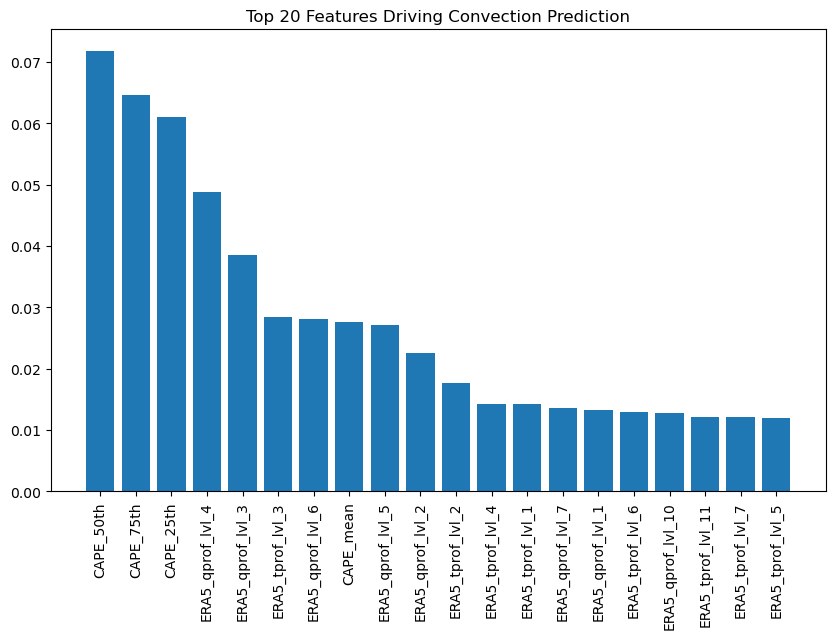

In [20]:
import matplotlib.pyplot as plt

# Get feature importance from the trained model
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the top 20 features
plt.figure(figsize=(10, 6))
plt.title("Top 20 Features Driving Convection Prediction")
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.show()

# Logistic Regression

In [21]:
# 1. Initialize the model
# class_weight='balanced' is still strictly necessary for your rare target events!
# max_iter=1000 ensures the math solver has enough time to converge on complex climate data
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Train the model (Using SCALED data)
lr_model.fit(X_train_scaled, y_train)

# 3. Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

# --- 4. EVALUATION ---
print("--- Logistic Regression Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_lr))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Confusion Matrix ---
[[ 499  319]
 [ 905 3704]]

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.36      0.61      0.45       818
           1       0.92      0.80      0.86      4609

    accuracy                           0.77      5427
   macro avg       0.64      0.71      0.65      5427
weighted avg       0.84      0.77      0.80      5427

